# Análisis de Retención y Churn de Clientes

## Contexto

La cadena de gimnasios Model Fitness busca mejorar su estrategia de retención de clientes y reducir la tasa de cancelación.

A partir de datos sobre características de los usuarios, frecuencia de visitas, contratos y comportamiento dentro del gimnasio, se analizarán los factores relacionados con el churn y se construirán modelos capaces de identificar clientes con mayor riesgo de abandono.

## Objetivo

El proyecto tiene como objetivos principales:

- Analizar las características de los clientes y detectar patrones asociados con la cancelación.
- Identificar los factores que tienen mayor relación con el churn.
- Segmentar a los clientes mediante técnicas de clustering.
- Construir y comparar modelos de clasificación para predecir la probabilidad de abandono.
- Formular recomendaciones de negocio orientadas a mejorar la retención de clientes.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score

gym = pd.read_csv('/content/gym_churn_us.csv')

## Revisión inicial de los datos

Se revisará la estructura, dimensiones, tipos de datos y calidad básica del dataset antes de comenzar el análisis exploratorio.

In [6]:
print('Dimensiones:', gym.shape)

display(gym.head())

print('\nInformación general:')
gym.info()

print('\nValores ausentes:')
display(gym.isna().sum())

print('\nDuplicados:')
print(gym.duplicated().sum())

Dimensiones: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total         

,0
gender,0
Near_Location,0
Partner,0
Promo_friends,0
Phone,0
Contract_period,0
Group_visits,0
Age,0
Avg_additional_charges_total,0
Month_to_end_contract,0



Duplicados:
0


## Preparación de los datos

El dataset no presenta valores ausentes ni registros duplicados. A continuación se estandarizarán los nombres de las columnas para facilitar el análisis.

In [7]:
gym.columns = gym.columns.str.lower()

gym.columns.tolist()

['gender',
 'near_location',
 'partner',
 'promo_friends',
 'phone',
 'contract_period',
 'group_visits',
 'age',
 'avg_additional_charges_total',
 'month_to_end_contract',
 'lifetime',
 'avg_class_frequency_total',
 'avg_class_frequency_current_month',
 'churn']

## Análisis exploratorio de datos

Se analizarán las principales características de los clientes para identificar patrones generales y posibles diferencias relacionadas con la cancelación.

In [8]:
gym.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


### Comparación de clientes según churn

Se compararán los valores promedio de las principales variables entre los clientes que permanecieron en el gimnasio y aquellos que cancelaron su membresía.

In [9]:
churn_comparison = gym.groupby('churn').mean().T

churn_comparison.columns = ['permanece', 'churn']

churn_comparison

,permanece,churn
gender,0.510037,0.510839
near_location,0.873086,0.768143
partner,0.534195,0.355325
promo_friends,0.353522,0.183789
phone,0.903709,0.902922
contract_period,5.747193,1.728558
group_visits,0.464103,0.268615
age,29.976523,26.989632
avg_additional_charges_total,158.445715,115.082899
month_to_end_contract,5.283089,1.662582


### Distribución de variables según churn

Se analizará la distribución de las principales variables numéricas para identificar diferencias de comportamiento entre los clientes que permanecen y aquellos que cancelan su membresía.

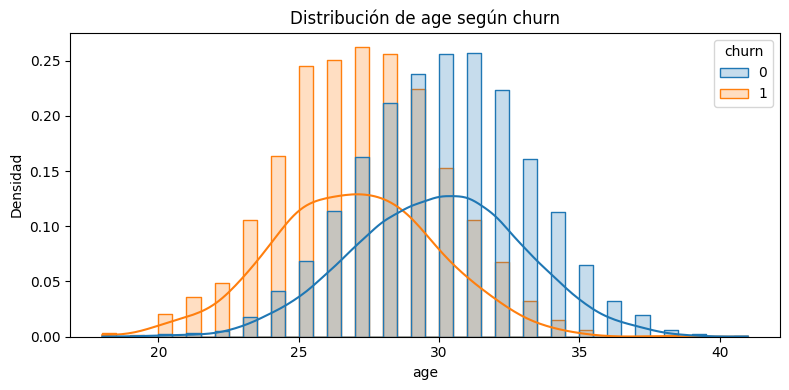

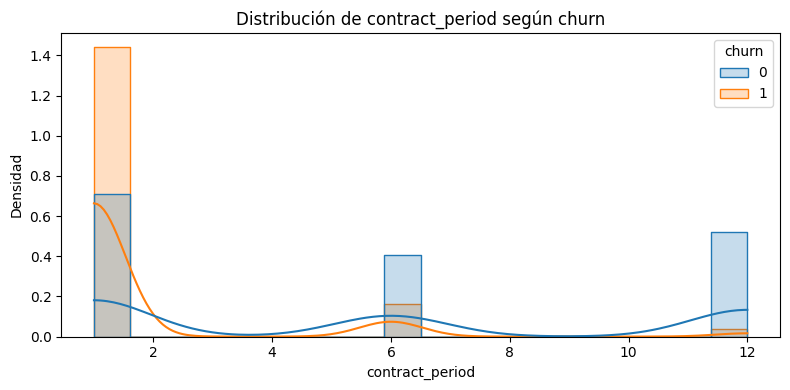

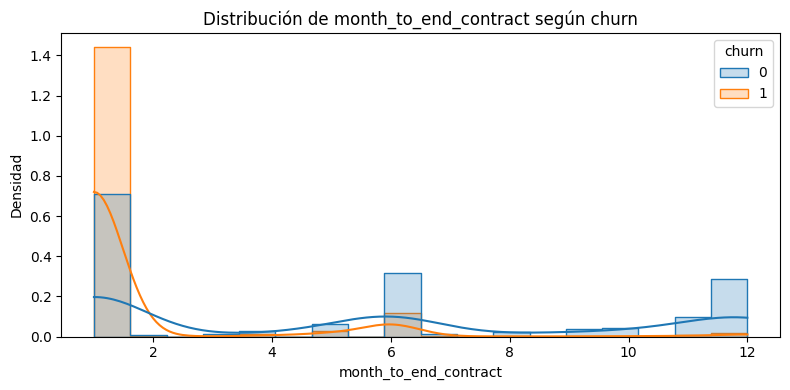

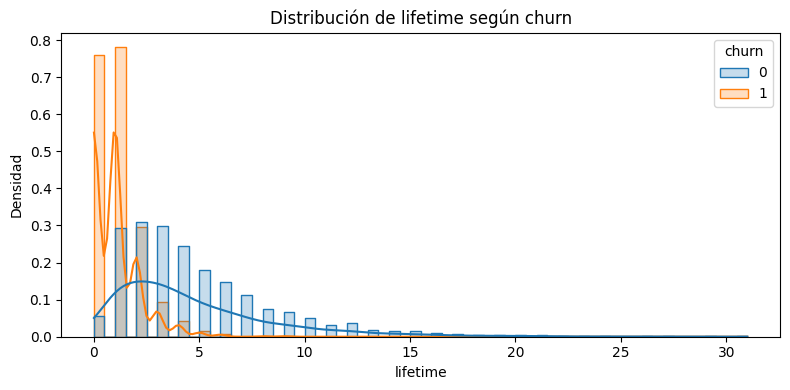

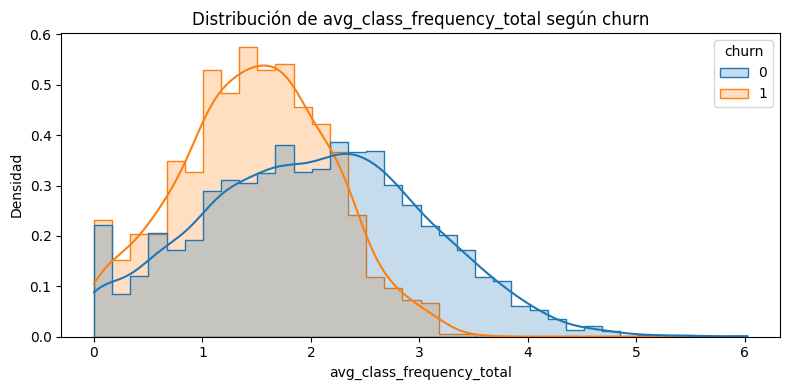

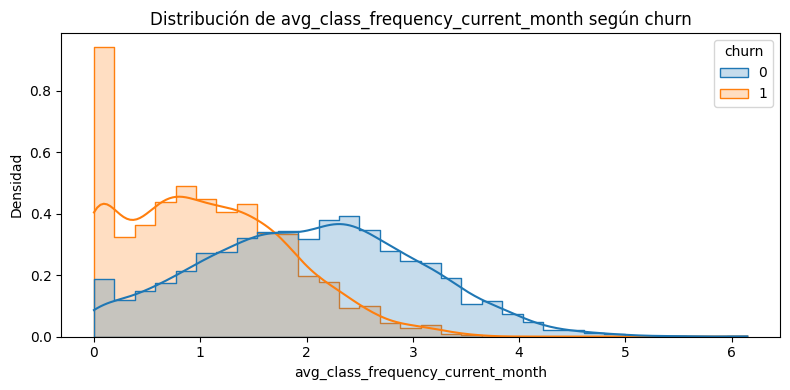

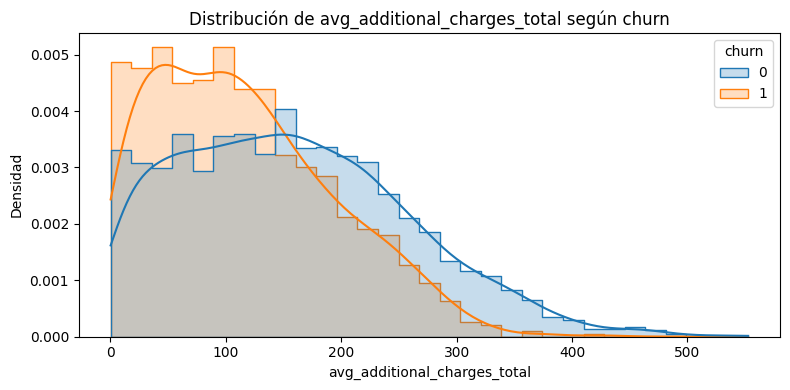

In [10]:
numeric_columns = [
    'age',
    'contract_period',
    'month_to_end_contract',
    'lifetime',
    'avg_class_frequency_total',
    'avg_class_frequency_current_month',
    'avg_additional_charges_total'
]

for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=gym,
        x=column,
        hue='churn',
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )

    plt.title(f'Distribución de {column} según churn')
    plt.xlabel(column)
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

### Matriz de correlación

Se analizarán las relaciones entre las variables numéricas para identificar cuáles presentan una mayor asociación con el churn y detectar posibles relaciones fuertes entre variables explicativas.

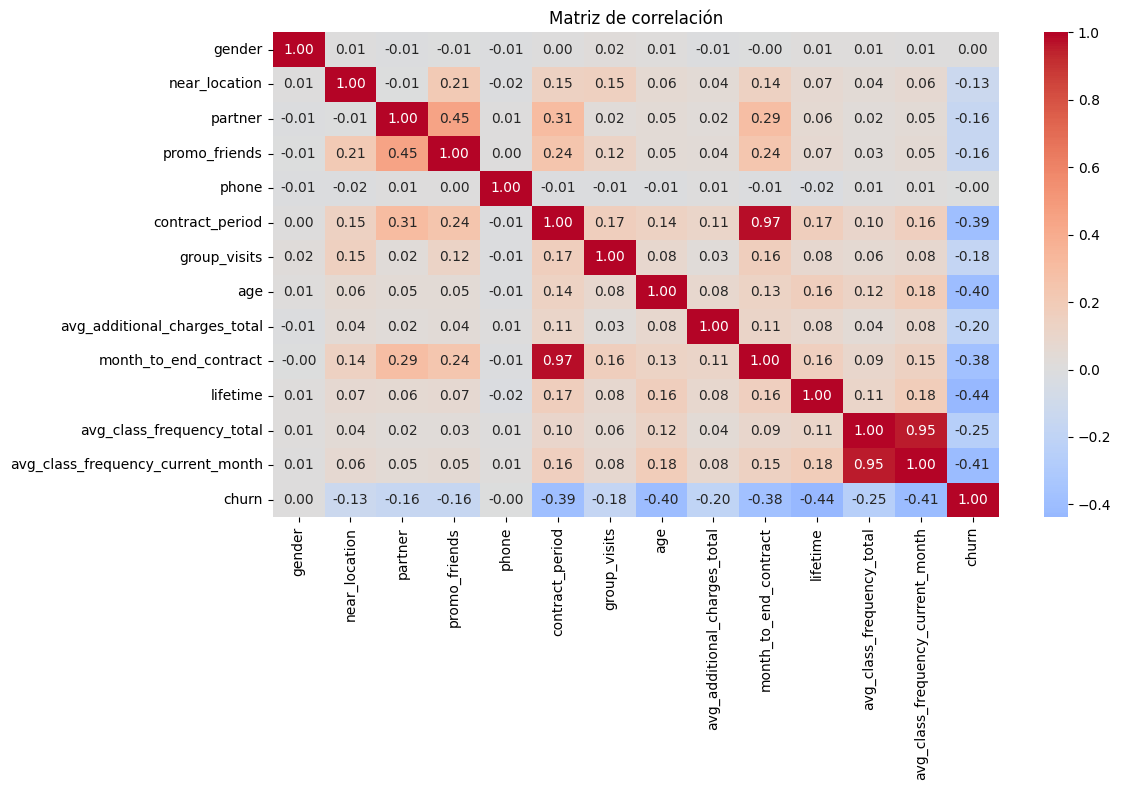

In [11]:
correlation_matrix = gym.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [12]:
churn_correlations = (
    correlation_matrix['churn']
    .drop('churn')
    .sort_values()
)

churn_correlations

,churn
lifetime,-0.438220
avg_class_frequency_current_month,-0.412348
age,-0.404735
contract_period,-0.389984
month_to_end_contract,-0.381393
avg_class_frequency_total,-0.249715
avg_additional_charges_total,-0.198697
group_visits,-0.175325
promo_friends,-0.162233
partner,-0.157986


### Conclusiones del análisis exploratorio

El análisis muestra que el churn no depende de una única característica, sino de una combinación de factores relacionados principalmente con la permanencia y el nivel de actividad del cliente.

Entre las variables que presentan una mayor relación con la cancelación destacan:

- la duración del contrato;
- los meses restantes del contrato;
- la antigüedad del cliente;
- la frecuencia de visitas al gimnasio;
- la edad;
- la participación en actividades grupales.

En general, los clientes con contratos más largos, mayor antigüedad y una frecuencia de asistencia más elevada presentan una menor tendencia al abandono.

Estos patrones sugieren que la **adopción del servicio y la vinculación del cliente con el gimnasio** pueden desempeñar un papel importante en la retención.

## Modelado predictivo de churn

Se construirán modelos de clasificación para predecir la probabilidad de abandono de los clientes.

Se compararán dos algoritmos:

- **Regresión logística**
- **Random Forest**

El objetivo es evaluar cuál ofrece un mejor desempeño para identificar clientes con riesgo de churn.

In [13]:
X = gym.drop('churn', axis=1)
y = gym['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (3200, 13)
Prueba: (800, 13)


### Preparación de variables

Las variables se estandarizarán antes de entrenar la regresión logística para evitar que diferencias de escala influyan en el modelo.

El escalador se ajustará únicamente con los datos de entrenamiento para evitar fuga de información.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Modelo 1: Regresión logística

Se entrenará un modelo de regresión logística utilizando las variables estandarizadas para predecir si un cliente abandonará el gimnasio.

In [15]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

In [16]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)

print('Accuracy:', round(accuracy_logistic, 3))
print('Precision:', round(precision_logistic, 3))
print('Recall:', round(recall_logistic, 3))

Accuracy: 0.925
Precision: 0.88
Recall: 0.83


### Resultados de la regresión logística

- El modelo de regresión logística obtiene un **accuracy del 92.5%**, lo que indica un buen desempeño general en la clasificación de los clientes.

- La precisión alcanza el **88%**, por lo que la mayoría de los clientes identificados como posibles casos de churn realmente pertenecen a ese grupo.

- El recall es del **83%**, lo que significa que el modelo consigue detectar aproximadamente 8 de cada 10 clientes que terminan abandonando.

  Desde una perspectiva de negocio, esta métrica es especialmente relevante, ya que detectar anticipadamente a los clientes con riesgo de cancelación permitiría aplicar acciones de retención antes de que abandonen.

### Modelo 2: Random Forest

Se entrenará un modelo Random Forest para comparar su capacidad predictiva con la regresión logística.

In [17]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)

In [18]:
accuracy_forest = accuracy_score(y_test, y_pred_forest)
precision_forest = precision_score(y_test, y_pred_forest)
recall_forest = recall_score(y_test, y_pred_forest)

print('Accuracy:', round(accuracy_forest, 3))
print('Precision:', round(precision_forest, 3))
print('Recall:', round(recall_forest, 3))

Accuracy: 0.927
Precision: 0.885
Recall: 0.835


### Comparación de modelos

Ambos modelos presentan un desempeño elevado y resultados muy similares.

Random Forest obtiene ligeramente mejores resultados:

- **Accuracy:** 92.7%
- **Precision:** 88.5%
- **Recall:** 83.5%

La regresión logística alcanza:

- **Accuracy:** 92.5%
- **Precision:** 88.0%
- **Recall:** 83.0%

Aunque Random Forest presenta el mejor desempeño en las tres métricas, la diferencia entre ambos modelos es reducida.

Desde una perspectiva de retención, el recall es especialmente relevante porque representa la capacidad del modelo para identificar a los clientes que realmente terminarán abandonando.

Por tanto, **Random Forest presenta una ligera ventaja predictiva**, aunque ambos modelos podrían considerarse adecuados para este problema.

In [19]:
model_results = pd.DataFrame({
    'modelo': [
        'Regresión logística',
        'Random Forest'
    ],
    'accuracy': [
        accuracy_logistic,
        accuracy_forest
    ],
    'precision': [
        precision_logistic,
        precision_forest
    ],
    'recall': [
        recall_logistic,
        recall_forest
    ]
})

model_results = model_results.round(3)

model_results

,modelo,accuracy,precision,recall
0,Regresión logística,0.925,0.880,0.830
1,Random Forest,0.928,0.885,0.835


## Segmentación de clientes

Además de predecir el churn de forma individual, se utilizarán técnicas de clustering para identificar grupos de clientes con comportamientos y características similares.

Esta segmentación permitirá analizar qué perfiles presentan una mayor tasa de abandono y orientar acciones de retención específicas para cada grupo.

In [20]:
# Estandarizar las variables para el clustering
scaler_cluster = StandardScaler()

X_scaled = scaler_cluster.fit_transform(
    gym.drop('churn', axis=1)
)

### Dendrograma de clientes

Se utilizará clustering jerárquico para visualizar cómo se agrupan los clientes según sus características y obtener una referencia para seleccionar el número de clústeres.

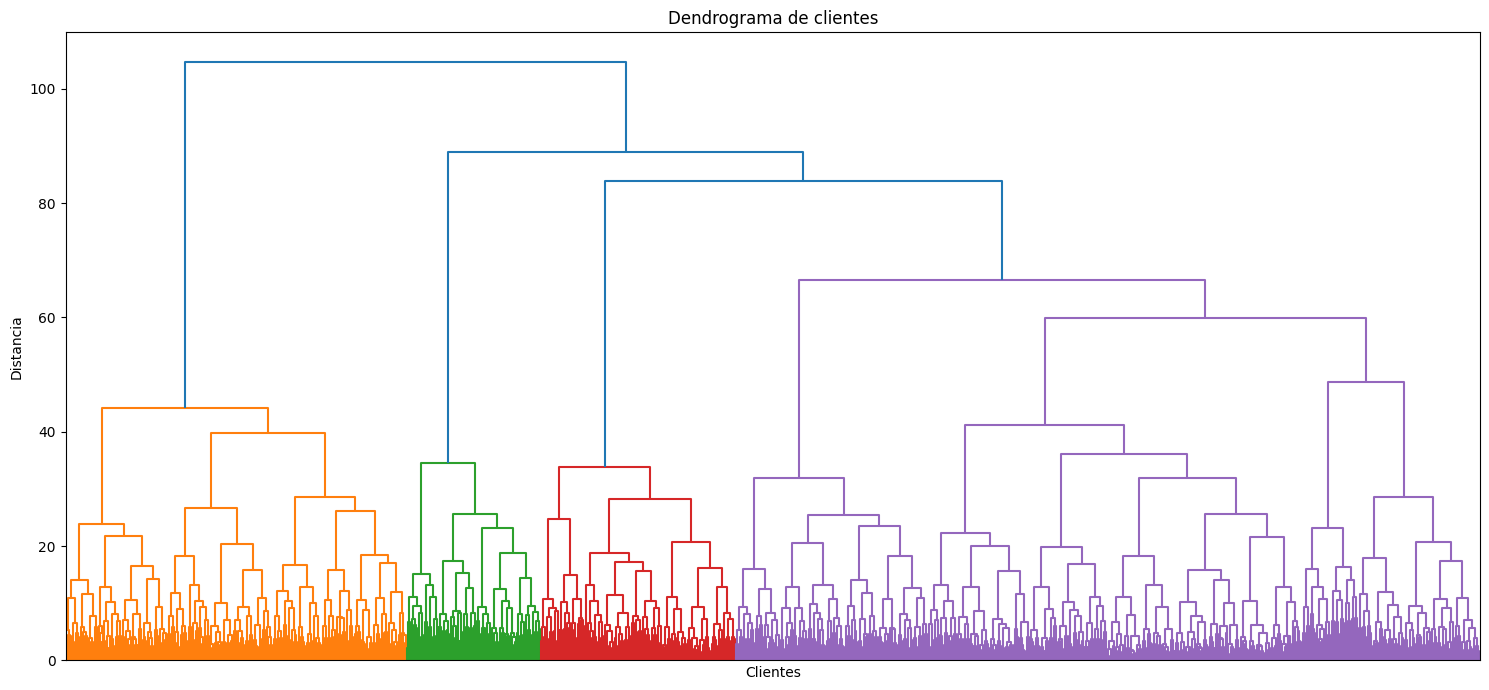

In [21]:
linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(15, 7))

dendrogram(
    linked,
    orientation='top',
    no_labels=True
)

plt.title('Dendrograma de clientes')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

### Segmentación mediante K-Means

A partir de la estructura observada en el dendrograma, se dividirá la base de clientes en cinco segmentos mediante K-Means.

El objetivo es identificar perfiles con características y niveles de churn diferentes.

In [22]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

gym['cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = (
    gym['cluster']
    .value_counts()
    .sort_index()
)

cluster_sizes

,count
cluster,
0,544
1,936
2,646
3,1107
4,767


### Perfil de los clústeres

Se analizarán los valores promedio de cada variable por clúster para identificar las características que distinguen a los diferentes segmentos de clientes.

In [23]:
cluster_profiles = (
    gym.groupby('cluster')
    .mean()
    .round(2)
)

cluster_profiles

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.50,0.00,0.47,0.08,0.92,2.21,0.22,28.48,133.63,2.07,2.78,1.66,1.47,0.45
1,0.50,0.94,0.74,0.49,0.90,11.88,0.55,29.93,164.63,10.88,4.67,2.00,1.99,0.02
2,0.49,1.00,0.82,1.00,0.90,3.17,0.46,29.22,141.87,2.93,3.74,1.74,1.64,0.25
3,0.49,1.00,0.24,0.02,0.90,1.99,0.32,28.21,131.15,1.90,2.39,1.27,1.03,0.53
4,0.59,0.97,0.26,0.09,0.90,2.81,0.48,30.14,161.88,2.59,5.15,2.88,2.88,0.07


### Interpretación de los segmentos

La segmentación muestra diferencias importantes en el riesgo de abandono.

- **Clúster 3:** presenta la mayor tasa de churn, con un 53%. Sus clientes tienen contratos cortos, menor antigüedad y una frecuencia de asistencia reducida.
- **Clúster 0:** alcanza un churn del 45% y se caracteriza especialmente por clientes que no viven cerca del gimnasio.
- **Clúster 2:** presenta un nivel de riesgo intermedio, con un churn del 25%.
- **Clúster 4:** muestra una tasa de churn baja, del 7%, asociada a clientes con mayor antigüedad y una frecuencia de asistencia elevada.
- **Clúster 1:** es el segmento más estable, con apenas un 2% de churn. Sus clientes suelen tener contratos largos, mayor permanencia y una frecuencia de visitas alta.

En conjunto, los resultados refuerzan la importancia de la **frecuencia de uso, la duración del contrato y la permanencia del cliente** como señales relevantes para la retención.

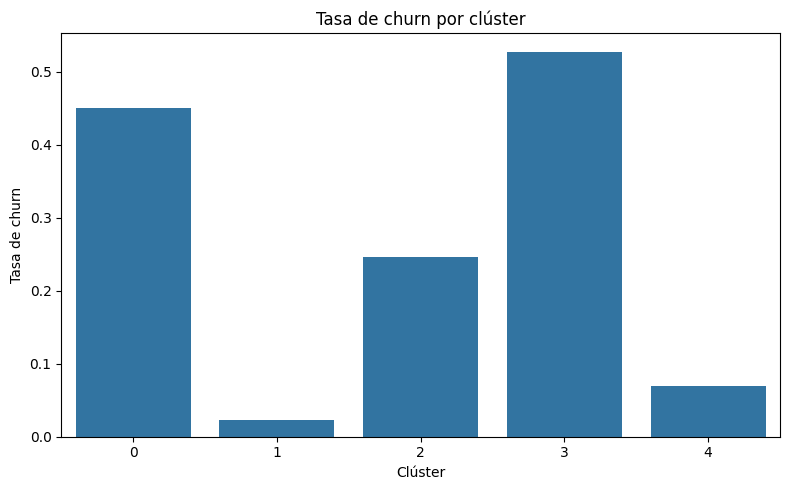

In [24]:
cluster_churn = (
    gym.groupby('cluster')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_churn.index,
    y=cluster_churn.values
)

plt.title('Tasa de churn por clúster')
plt.xlabel('Clúster')
plt.ylabel('Tasa de churn')
plt.tight_layout()
plt.show()

## Recomendaciones de retención por segmento

A partir de los perfiles identificados, las acciones de retención deberían adaptarse al nivel de riesgo y comportamiento de cada grupo.

### Clúster 3 — Riesgo muy alto

Es el segmento más crítico, con una tasa de churn cercana al 53%.

Sus clientes presentan contratos cortos, menor antigüedad y baja frecuencia de asistencia.

**Acciones recomendadas:**
- campañas de reactivación ante caídas en la frecuencia de visitas;
- incentivos para extender la duración del contrato;
- seguimiento durante los primeros meses de membresía;
- recomendaciones personalizadas de clases o actividades para incrementar el uso del gimnasio.

### Clúster 0 — Riesgo alto

Presenta una tasa de churn aproximada del 45% y se caracteriza principalmente por clientes que no viven cerca del gimnasio.

**Acciones recomendadas:**
- aumentar el valor percibido de la membresía mediante beneficios adicionales;
- promover horarios y servicios que reduzcan la fricción asociada al desplazamiento;
- ofrecer incentivos de renovación antes de la finalización del contrato.

### Clúster 2 — Riesgo medio

Su tasa de churn ronda el 25%.

**Acciones recomendadas:**
- monitorizar cambios en frecuencia de asistencia;
- incentivar una mayor participación en actividades grupales;
- aplicar campañas preventivas antes de que aparezcan señales más claras de abandono.

### Clústeres 1 y 4 — Alta retención

Estos segmentos presentan las tasas de churn más bajas.

Sus clientes suelen mostrar mayor frecuencia de visitas, mayor antigüedad y, especialmente en el clúster 1, contratos de mayor duración.

**Acciones recomendadas:**
- reforzar programas de fidelización;
- fomentar recomendaciones y programas de referidos;
- identificar qué elementos de su experiencia pueden replicarse en los segmentos de mayor riesgo.

### Implicación de negocio

La estrategia de retención no debería aplicarse de forma uniforme a toda la base de clientes.

La combinación de **predicción individual de churn y segmentación de clientes** permite priorizar recursos sobre los usuarios con mayor riesgo y diseñar intervenciones específicas según su comportamiento.

## Conclusión final

El análisis permitió identificar patrones claros asociados con la cancelación de clientes y construir una estrategia de retención basada en datos.

### Principales hallazgos

- Los clientes con **contratos más cortos, menor antigüedad y menor frecuencia de asistencia** presentan un mayor riesgo de churn.
- La frecuencia de uso del gimnasio aparece como una de las señales más relevantes para anticipar posibles abandonos.
- Los modelos de clasificación alcanzan un desempeño elevado:
  - **Regresión logística:** accuracy 92.5%, precision 88.0% y recall 83.0%.
  - **Random Forest:** accuracy 92.7%, precision 88.5% y recall 83.5%.
- Random Forest presenta una ligera ventaja predictiva, aunque ambos modelos ofrecen resultados muy similares.
- La segmentación mediante K-Means permitió identificar cinco perfiles de clientes con niveles de churn muy diferentes.
- Los clústeres 3 y 0 concentran el mayor riesgo de abandono, mientras que los clústeres 1 y 4 muestran una elevada retención.

### Recomendación de negocio

La estrategia de retención debería combinar dos enfoques:

1. **Predicción individual**, utilizando el modelo de churn para detectar clientes con mayor probabilidad de abandono.
2. **Segmentación**, adaptando las acciones de retención al comportamiento y características de cada grupo.

Los esfuerzos deberían priorizar especialmente a clientes con baja frecuencia de visitas, contratos cortos y poca antigüedad, aplicando acciones tempranas de reactivación, seguimiento e incentivos de renovación.

Este enfoque permitiría utilizar los recursos de retención de forma más eficiente y actuar antes de que el abandono se produzca.

----------------------------------------

In [25]:
import os

os.makedirs('/content/images', exist_ok=True)

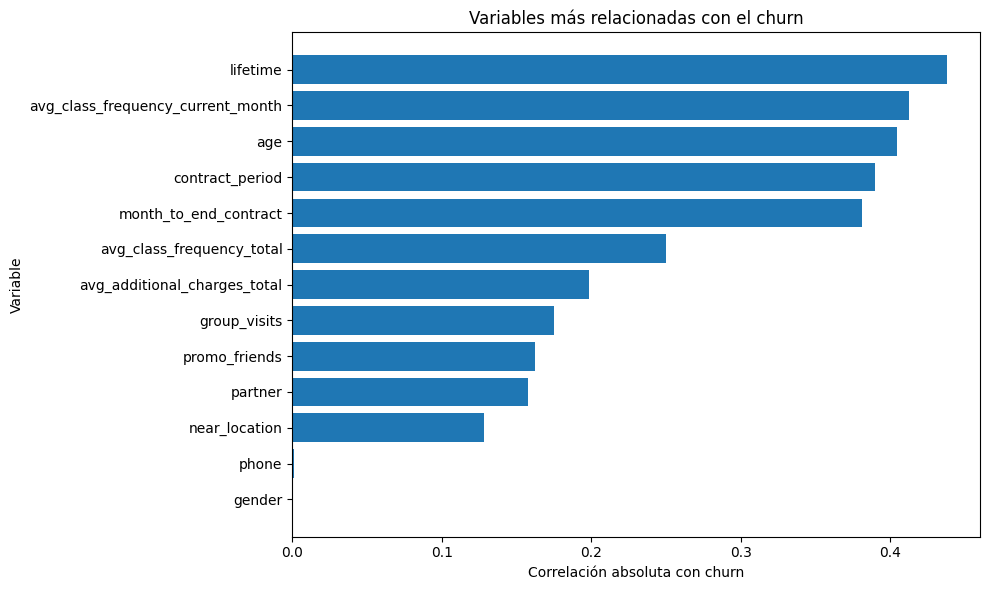

In [26]:
# Visual 1: Variables más relacionadas con churn

churn_visual = (
    churn_correlations
    .abs()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    churn_visual.index,
    churn_visual.values
)

plt.title('Variables más relacionadas con el churn')
plt.xlabel('Correlación absoluta con churn')
plt.ylabel('Variable')

plt.tight_layout()

plt.savefig(
    '/content/images/variables_relacionadas_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

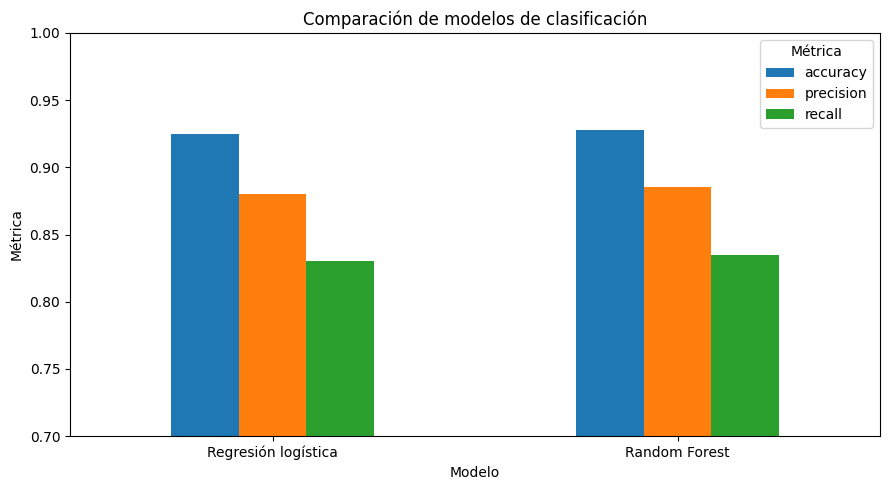

In [27]:
# Visual 2: Comparación de modelos

model_plot = model_results.set_index('modelo')

model_plot.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Comparación de modelos de clasificación')
plt.xlabel('Modelo')
plt.ylabel('Métrica')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend(title='Métrica')

plt.tight_layout()

plt.savefig(
    '/content/images/comparacion_modelos.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

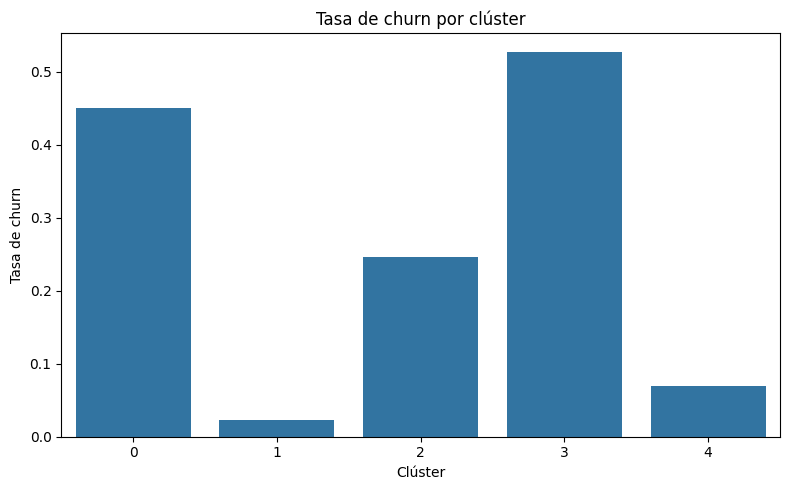

In [28]:
# Visual 3: Tasa de churn por clúster

cluster_churn_plot = (
    gym.groupby('cluster')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_churn_plot.index,
    y=cluster_churn_plot.values
)

plt.title('Tasa de churn por clúster')
plt.xlabel('Clúster')
plt.ylabel('Tasa de churn')

plt.tight_layout()

plt.savefig(
    '/content/images/churn_por_cluster.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()